In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import random

In [2]:
# ------------------- Load MNIST -------------------
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = x_train[..., np.newaxis]   # shape: (60000,28,28,1)
x_test = x_test[..., np.newaxis]     # shape: (10000,28,28,1)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [3]:

# ------------------- Data Augmentation -------------------
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)
datagen.fit(x_train)

In [4]:
# ------------------- Improved CNN -------------------
model = models.Sequential([
    layers.Input(shape=(28,28,1)),
    layers.Conv2D(32, 3, activation='relu'),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Conv2D(128, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [5]:
# ------------------- Train Model -------------------
history = model.fit(datagen.flow(x_train, y_train, batch_size=64),
                    epochs=15,
                    validation_data=(x_test, y_test))

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


938/938 ━━━━━━━━━━━━━━━━━━━━ 157s 166ms/step - accuracy: 0.7406 - loss: 0.7778 - val_accuracy: 0.9890 - val_loss: 0.0351
Epoch 2/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 155s 166ms/step - accuracy: 0.9490 - loss: 0.1712 - val_accuracy: 0.9909 - val_loss: 0.0270
Epoch 3/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 159s 169ms/step - accuracy: 0.9629 - loss: 0.1242 - val_accuracy: 0.9940 - val_loss: 0.0195
Epoch 4/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 156s 166ms/step - accuracy: 0.9693 - loss: 0.1033 - val_accuracy: 0.9927 - val_loss: 0.0223
Epoch 5/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 157s 168ms/step - accuracy: 0.9721 - loss: 0.0951 - val_accuracy: 0.9941 - val_loss: 0.0181
Epoch 6/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 194s 160ms/step - accuracy: 0.9756 - loss: 0.0815 - val_accuracy: 0.9949 - val_loss: 0.0151
Epoch 7/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 153s 163ms/step - accuracy: 0.9768 - loss: 0.0805 - val_accuracy: 0.9939 - val_loss: 0.0179
Epoch 8/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 152s 162ms/step - accuracy: 0.9791 - loss: 0.07

In [7]:
# ------------------- Save Model -------------------
model.save("mnist_model.h5")
print("✅ Model saved as mnist_model.h5")

✅ Model saved as mnist_model.h5


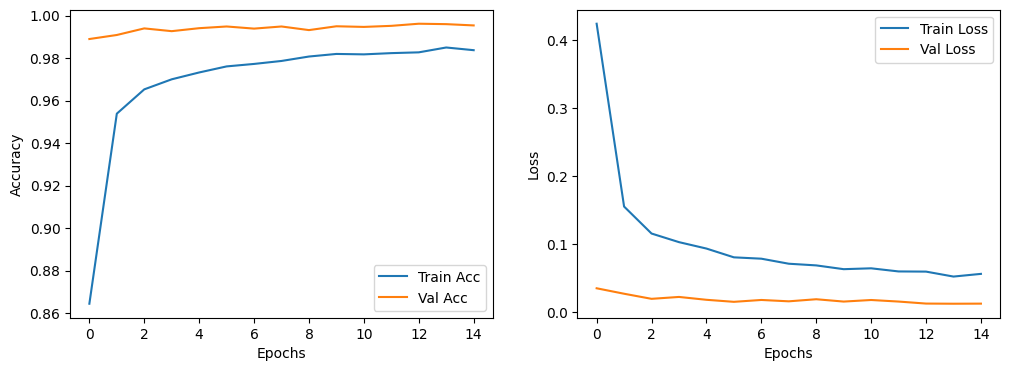

In [6]:
# ------------------- Plot Training History -------------------
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend()
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


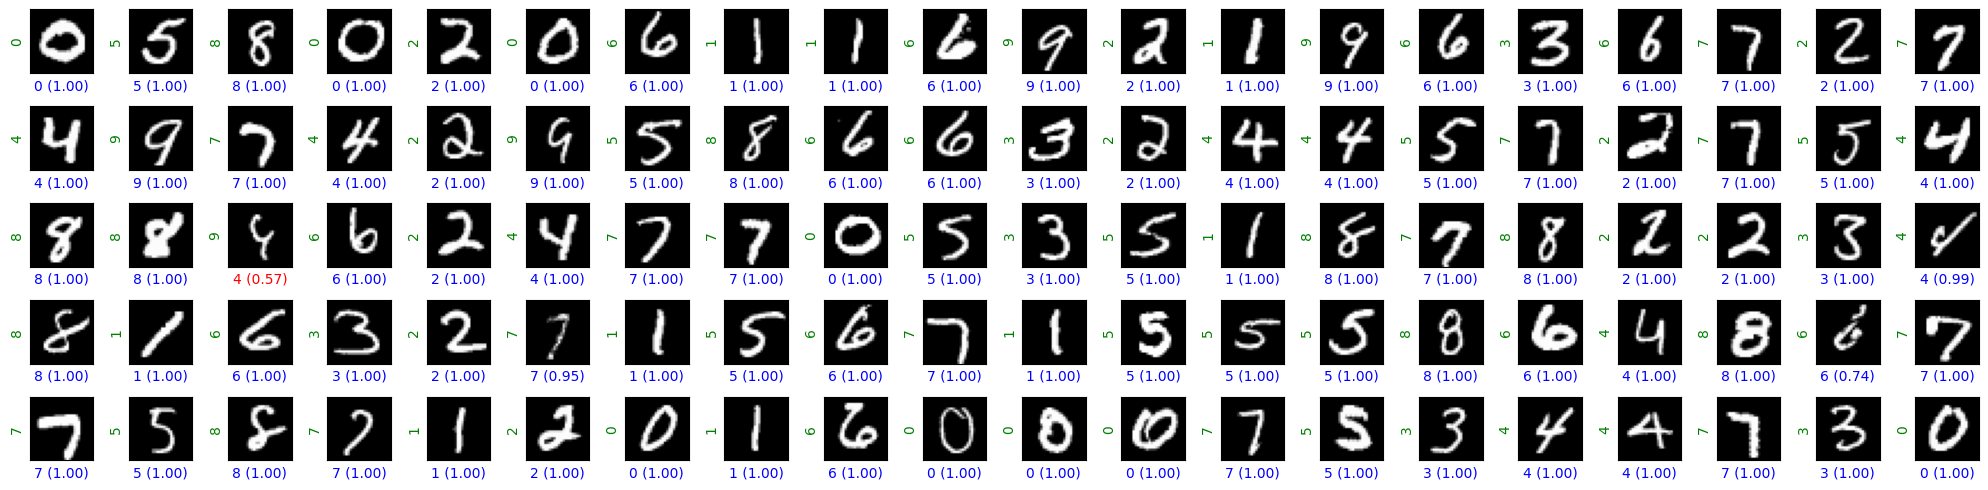

In [8]:
# ------------------- Visualize Random Sample Predictions -------------------
ROWS = 5
COLS = 20

random_indices = random.sample(range(x_test.shape[0]), ROWS*COLS)
sample_images = x_test[random_indices, :]
sample_labels = y_test[random_indices]
predictions = model.predict(sample_images)

i = 0
plt.figure(figsize=(20,5))
for r in range(ROWS):
    for c in range(COLS):
        plt.subplot(ROWS, COLS, i+1)
        plt.imshow(sample_images[i].reshape(28,28), cmap=plt.cm.gray)
        plt.xticks([]); plt.yticks([])
        prediction = np.argmax(predictions[i])
        confidence = predictions[i][prediction]
        if sample_labels[i] == prediction:
            plt.xlabel(f"{prediction} ({confidence:.2f})", color='b')
        else:
            plt.xlabel(f"{prediction} ({confidence:.2f})", color='r')
        plt.ylabel(sample_labels[i], color='g')
        i += 1
plt.tight_layout()
plt.show()

In [9]:
# ------------------- Test Single Image -------------------
def test(i):
    img = x_test[i]
    img_input = img.reshape(1,28,28,1)   # match model input shape
    predictions = model.predict(img_input)

    plt.figure()
    plt.imshow(img.reshape(28,28), cmap='gray_r')
    plt.xticks([]); plt.yticks([])
    plt.ylabel(f"True Label: {y_test[i]}", color='g') # ground truth

    prediction = np.argmax(predictions)
    confidence = predictions[0][prediction]

    if y_test[i] == prediction:
        plt.xlabel(f"Prediction = {prediction} (Confidence = {confidence:.2f})", color='b')
    else:
        plt.xlabel(f"Prediction = {prediction} (Confidence = {confidence:.2f})", color='r')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


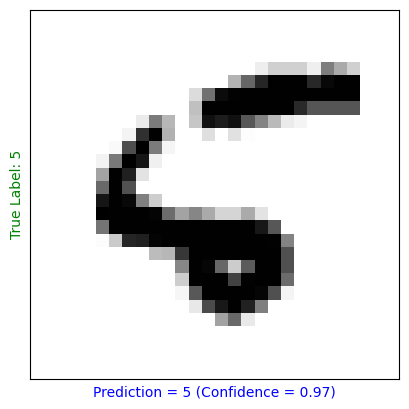

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


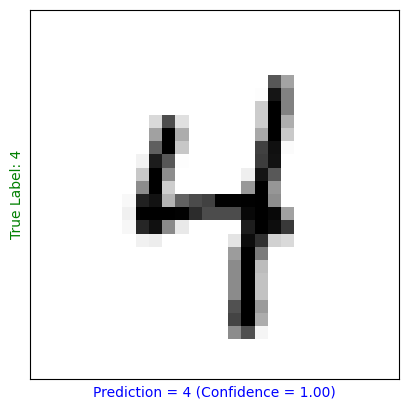

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


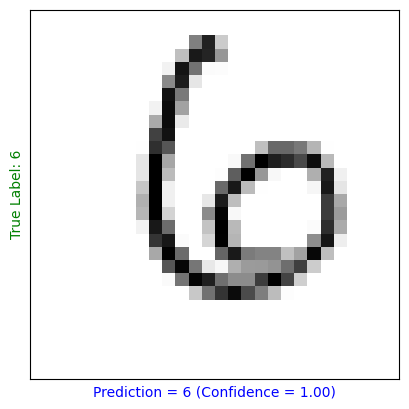

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


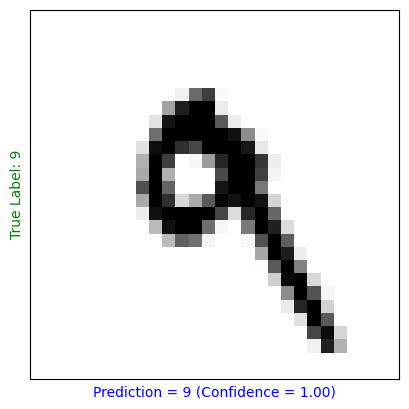

In [10]:

# Example test
test(8)
test(19)
test(100)
test(7)